Sigmas         : [0.1, 0.2, 0.3, 0.4, 0.5]
True prices    : [np.float64(2.291824712793514), np.float64(6.335113934907699), np.float64(10.553375414009693), np.float64(14.738536676964332), np.float64(18.79269177114296)]
MC errors      : [np.float64(0.002539202513692995), np.float64(0.08181932492988153), np.float64(0.09215402976718678), np.float64(0.2779845882754248), np.float64(0.8061526097654372)]
QAE errors     : [np.float64(0.031320837747646824), np.float64(0.1553362600757513), np.float64(0.11124835603867922), np.float64(0.055700398790614614), np.float64(0.3715828115796711)]


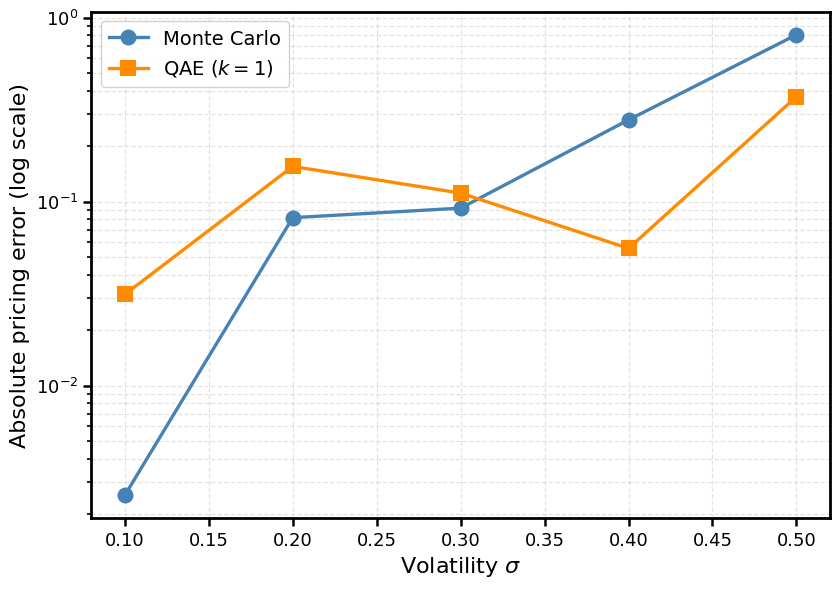

In [11]:
import numpy as np
import math
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer.primitives import Sampler

sampler = Sampler()

# -----------------------------
# Core single-qubit QAE helpers
# -----------------------------
def build_single_qubit_QAE(p_true: float):
    theta_prep = 2 * math.asin(math.sqrt(p_true))

    A = QuantumCircuit(1)
    A.ry(theta_prep, 0)

    Q = QuantumCircuit(1)
    Q.ry(theta_prep, 0)
    Q.z(0)
    Q.ry(-theta_prep, 0)
    Q.x(0); Q.z(0); Q.x(0)

    return A, Q

def qae_invert_amplitude(p_true: float, k: int, p_k: float) -> float:
    if k == 0:
        return p_k
    p_k = max(0.0, min(1.0, p_k))
    alpha = math.asin(math.sqrt(p_k))
    theta1 = alpha / (2*k + 1)
    theta2 = (math.pi - alpha) / (2*k + 1)
    p1 = math.sin(theta1)**2
    p2 = math.sin(theta2)**2
    return p1 if abs(p1 - p_true) < abs(p2 - p_true) else p2

def run_QAE(p_true: float, k: int, shots: int = 5000):
    A, Q = build_single_qubit_QAE(p_true)
    qc = QuantumCircuit(1, 1)
    qc.compose(A, inplace=True)
    for _ in range(k):
        qc.compose(Q, inplace=True)
    qc.measure(0, 0)
    dist = sampler.run([qc], shots=shots).result().quasi_dists[0]
    p_k = dist.get(1, 0.0)
    p_hat = qae_invert_amplitude(p_true, k, p_k)
    return p_hat, p_k

# -----------------------------
# GBM simulation + discretised "true" price
# -----------------------------
def simulate_GBM_terminal(S0, mu, sigma, T, N_paths):
    Z = np.random.normal(0, 1, size=N_paths)
    ST = S0 * np.exp((mu - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    return ST

def european_call_payoff(S, K):
    return np.maximum(S - K, 0.0)

# -----------------------------
# Validation 11: volatility sweep
# -----------------------------
np.random.seed(123)

S0 = 100.0
mu = 0.05
K  = 110.0
T  = 1.0

sigmas     = [0.1, 0.2, 0.3, 0.4, 0.5]
N_true     = 200000   # large MC to approximate "true" price
N_mc       = 30000    # MC for comparison
shots_qae  = 5000
k_qae      = 1        # stable amplification
C_global   = 500.0    # scaling to keep p_true small across all sigmas

mc_errors  = []
qae_errors = []
true_prices = []
mc_prices = []
qae_prices = []

for sigma in sigmas:
    # "True" price from large MC
    ST_big = simulate_GBM_terminal(S0, mu, sigma, T, N_true)
    pay_big = european_call_payoff(ST_big, K)
    true_price = pay_big.mean()
    true_prices.append(true_price)

    # MC with moderate N
    ST_mc = simulate_GBM_terminal(S0, mu, sigma, T, N_mc)
    pay_mc = european_call_payoff(ST_mc, K)
    mc_price = pay_mc.mean()
    mc_prices.append(mc_price)

    # QAE: scale expectation to amplitude domain
    p_true = true_price / C_global
    # ensure safety
    if p_true > 0.25:
        # rescale if needed (rare for these parameters)
        C = true_price / 0.2
    else:
        C = C_global
        p_true = true_price / C

    p_hat, p_k = run_QAE(p_true, k_qae, shots_qae)
    qae_price = C * p_hat
    qae_prices.append(qae_price)

    mc_errors.append(abs(mc_price  - true_price))
    qae_errors.append(abs(qae_price - true_price))

print("Sigmas         :", sigmas)
print("True prices    :", true_prices)
print("MC errors      :", mc_errors)
print("QAE errors     :", qae_errors)

# -----------------------------
# Plot errors vs volatility
# -----------------------------
plt.rcParams.update({"axes.linewidth": 2.0})

fig, ax = plt.subplots(figsize=(8.5, 6))
ax.set_yscale("log")

ax.plot(sigmas, mc_errors, 'o-', color="steelblue",
        linewidth=2.4, markersize=10, markeredgewidth=1.5, label="Monte Carlo")
ax.plot(sigmas, qae_errors, 's-', color="darkorange",
        linewidth=2.4, markersize=10, markeredgewidth=1.5, label=f"QAE ($k={k_qae}$)")

ax.set_xlabel(r"Volatility $\sigma$", fontsize=16)
ax.set_ylabel("Absolute pricing error (log scale)", fontsize=16)

ax.tick_params(axis='both', which='major', labelsize=13, width=1.8, length=6)
ax.tick_params(axis='both', which='minor', width=1.2, length=3)
ax.grid(True, which="both", ls="--", alpha=0.35, linewidth=0.9)
ax.legend(fontsize=14, framealpha=0.9)

fig.tight_layout()
fig.savefig("volatility_regimes.pdf", bbox_inches="tight")   # use in LaTeX
fig.savefig("volatility_regimes.png", dpi=300, bbox_inches="tight")
plt.show()